In [4]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

pd.set_option('display.float_format', lambda x: '{:,.0f}'.format(x) if int(x) == x else '{:,.3f}'.format(x))

In [5]:
# We can load the pickle file of the cleaned data frame immediately
df_orig = pd.read_pickle('clean_df.pkl')
df_orig.head()
df = df_orig  # make a copy
df.shape

(562, 8)

In [6]:
X = df.drop(columns=['salary_in_usd'])
y = df['salary_in_usd']  # target
print(f"X shape: {X.shape}, y shape: {y.shape}")
X.head()

X shape: (562, 7), y shape: (562,)


,work_year,experience_level,job_title,remote_ratio,company_location,company_size,is_abroad
0,2020,MI,Data Scientist,0,DE,L,False
1,2020,SE,Machine Learning Scientist,0,Asia,S,False
2,2020,SE,Big Data Engineer,50,GB,M,False
3,2020,MI,Product Data Analyst,0,Latin America,S,False
4,2020,SE,Machine Learning Engineer,50,US,L,False


In [7]:
# Train on 90 % of the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

print(f'Train samples: {X_train.shape[0]}')
print(f'Test samples:  {X_test.shape[0]}')

Train samples: 505
Test samples:  57


In [8]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 505 entries, 86 to 111
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   work_year         505 non-null    int64 
 1   experience_level  505 non-null    object
 2   job_title         505 non-null    object
 3   remote_ratio      505 non-null    int64 
 4   company_location  505 non-null    object
 5   company_size      505 non-null    object
 6   is_abroad         505 non-null    bool  
dtypes: bool(1), int64(2), object(4)
memory usage: 28.1+ KB


In [9]:
def evaluate_regression(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {
        'model': model_name,
        'mae': round(mae, 4),
        'mse': round(mse, 4),
        'rmse': round(rmse, 4),
        'r2': round(r2, 4)
    }

In [10]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.2 MB/s eta 0:00:00


In [11]:
X_train.drop(columns=['work_year', 'is_abroad']).columns.tolist()

['experience_level',
 'job_title',
 'remote_ratio',
 'company_location',
 'company_size']

In [12]:
# We're going to train immediately on CatBoost because it works natively with
# categories. Then I can switch to a different DT model that needs encoding if
# I have time.
from catboost import CatBoostRegressor

# Drop year and is_abroad from the categorical features
cat_features = X_train.drop(columns=['work_year', 'is_abroad']).columns.tolist()

cb_reg = CatBoostRegressor(n_estimators=100, random_state=42)
cb_reg.fit(X_train, y_train, cat_features=cat_features, verbose=0)

cb_pred = cb_reg.predict(X_test)
cb_results = evaluate_regression('CatBoost', y_test, cb_pred)
cb_results

{'model': 'CatBoost',
 'mae': 38677.7042,
 'mse': 4100531654.8102,
 'rmse': np.float64(64035.3938),
 'r2': 0.3717}

In [13]:
cb_reg = CatBoostRegressor(n_estimators=500, depth=6, learning_rate=0.05, random_state=42, verbose=0)
cb_reg.fit(X_train, y_train, cat_features=cat_features, verbose=0)

cb_pred = cb_reg.predict(X_test)
cb_results = evaluate_regression('CatBoost', y_test, cb_pred)
cb_results

{'model': 'CatBoost',
 'mae': 33229.7584,
 'mse': 3217993835.0929,
 'rmse': np.float64(56727.3641),
 'r2': 0.507}

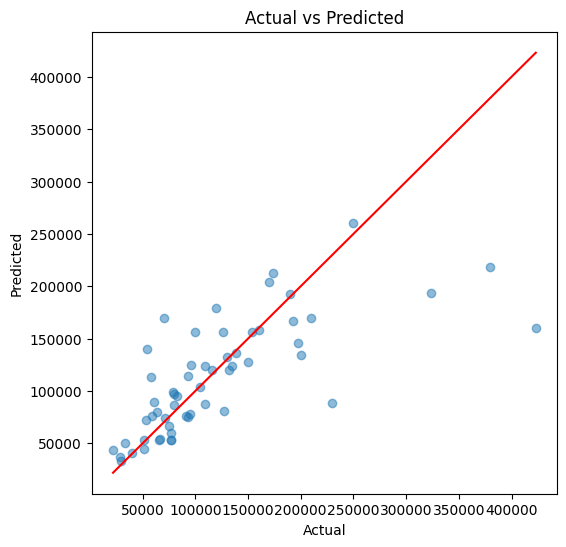

In [14]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, cb_pred, alpha=0.5)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'Actual vs Predicted')
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red')
plt.show()

In [15]:
# Save the model
joblib.dump(cb_reg, "w1_ds_salaries_model.joblib")

['w1_ds_salaries_model.joblib']

In [28]:
df_test = pd.concat([X_test, y_test], axis=1)
df_test.to_csv('llm_test_data.csv', index=False)

In [34]:
df['job_title'].unique()

array(['Data Scientist', 'Machine Learning Scientist',
       'Big Data Engineer', 'Product Data Analyst',
       'Machine Learning Engineer', 'Data Analyst', 'Lead Data Scientist',
       'Business Data Analyst', 'Lead Data Engineer', 'Lead Data Analyst',
       'Data Engineer', 'Data Science Consultant', 'BI Data Analyst',
       'Director of Data Science', 'Research Scientist',
       'Machine Learning Manager', 'Data Engineering Manager',
       'Machine Learning Infrastructure Engineer', 'AI Scientist',
       'Principal Data Scientist', 'Data Science Manager', 'Head of Data',
       'Data Analytics Engineer', 'Applied Data Scientist',
       'Marketing Data Analyst', 'Cloud Data Engineer',
       'Financial Data Analyst', 'Computer Vision Software Engineer',
       'Director of Data Engineering', 'Data Science Engineer',
       'Principal Data Engineer', 'Machine Learning Developer',
       'Applied Machine Learning Scientist', 'Computer Vision Engineer',
       'ML Engineer', 'D